<a href="https://colab.research.google.com/github/Noga-66/bbc-news-classifier/blob/main/bbc_news_classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BBC News Classification Project — Custom Transformer vs. Sentence Embeddings + ML



## 0) Install required packages

In [ ]:
!pip install -q sentence-transformers gensim scikit-learn transformers torch kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 56.0 MB/s eta 0:00:00


## 1) Get the dataset into Colab



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
!kaggle datasets download -d bhavikjikadara/bbc-news-articles -p /content/data
!unzip -oq /content/data/bbc-news-articles.zip -d /content/data

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/bbc-news-articles
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.11M/3.11M [00:01<00:00, 2.20MB/s]



In [ ]:
import pandas as pd
import re
import os

CSV_PATH = '/content/data/bbc_news_20220307_20240703.csv'

if os.path.exists(CSV_PATH):
    # Load the CSV
    tmp = pd.read_csv(CSV_PATH)
    print("Raw CSV loaded. Shape:", tmp.shape)

    # Combine title and description to make the training text
    tmp['text'] = tmp['title'].fillna('') + " " + tmp['description'].fillna('')

    # Function to parse categories from the BBC news URL/link column
    def extract_category(url):
        if pd.isna(url):
            return None
        match = re.search(r'bbc\.(?:co\.uk|com)/(news|sport|blogs|weather)/([^/?#]+)', url)
        if match:
            section, category = match.group(1), match.group(2)
            # If it's a general section, refine using sub-directories
            if category.isdigit() or len(category) < 2:
                return section
            # Return cleaner category names
            parts = category.split('-')
            return parts[0].strip().lower()
        return None

    tmp['category'] = tmp['link'].apply(extract_category)

    # Fill missing values and clean columns
    tmp['text'] = tmp['text'].str.strip()
    tmp = tmp.dropna(subset=['category', 'text'])

    valid_categories = ['world', 'sport', 'entertainment', 'business', 'technology', 'politics', 'science']
    df = tmp[tmp['category'].isin(valid_categories)][['text', 'category']].copy()

    df = df[df['text'] != ""].drop_duplicates().reset_index(drop=True)
else:
    df = pd.DataFrame(columns=['text', 'category'])

print("Final processed DataFrame shape:", df.shape)
if not df.empty:
    print("Unique categories detected:\n", df['category'].value_counts())
    display(df.head())
else:
    print("Warning: DataFrame is empty!")

Raw CSV loaded. Shape: (35860, 5)
Final processed DataFrame shape: (13290, 2)
Unique categories detected:
 category
world            8116
business         2277
entertainment    1849
science           548
technology        423
sport              77
Name: count, dtype: int64


,text,category
0,Ukraine: Angry Zelensky vows to punish Russian...,world
1,War in Ukraine: Taking cover in a town under a...,world
2,Ukraine war 'catastrophic for global food' One...,business
3,Ukraine conflict: Oil price soars to highest l...,business
4,TikTok limits services as Netflix pulls out of...,business


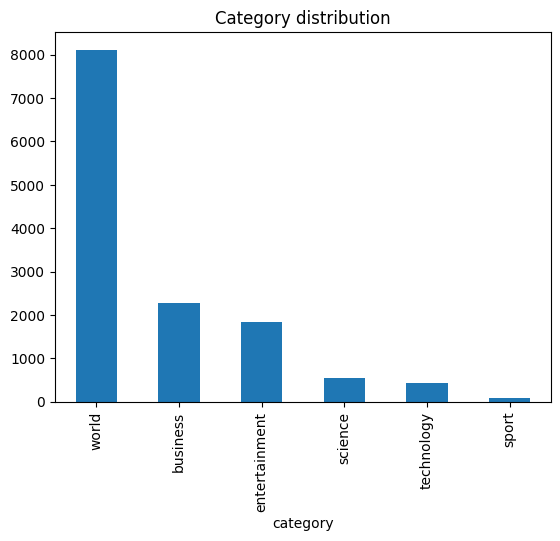

Mapped labels list: ['business', 'entertainment', 'science', 'sport', 'technology', 'world']


In [ ]:
import matplotlib.pyplot as plt

# Plot the category distribution
df['category'].value_counts().plot(kind='bar', title='Category distribution')
plt.show()

# Map categories to numerical labels
labels = sorted(df['category'].unique().tolist())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}
df['label_id'] = df['category'].map(label2id)
print("Mapped labels list:", labels)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label_id']
)
train_df, val_df = train_test_split(
    train_df, test_size=0.1, random_state=42, stratify=train_df['label_id']
)
print(len(train_df), len(val_df), len(test_df))

9568 1064 2658


---
# Part 1 — Transformer Encoder from scratch (Static Embeddings + Positional Encoding)


In [ ]:
import re
import numpy as np

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

train_tokens = train_df['text'].apply(simple_tokenize).tolist()
val_tokens = val_df['text'].apply(simple_tokenize).tolist()
test_tokens = test_df['text'].apply(simple_tokenize).tolist()

print(train_tokens[0][:20])

['thames', 'water', 'troubles', 'swell', 'as', 'parent', 'firm', 'defaults', 'holding', 'company', 'kemble', 'has', 'told', 'lenders', 'that', 'it', 'has', 'failed', 'to', 'meet']


In [ ]:
from gensim.models import Word2Vec

EMBED_DIM = 128

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=EMBED_DIM,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=20,
)

print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 11602


In [ ]:
# build a vocabulary that includes special PAD and UNK tokens
PAD_TOKEN, UNK_TOKEN = "<pad>", "<unk>"
vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word in w2v_model.wv.index_to_key:
    vocab[word] = len(vocab)

vocab_size = len(vocab)
print("vocab size:", vocab_size)
embedding_matrix = np.random.normal(scale=0.1, size=(vocab_size, EMBED_DIM)).astype(np.float32)
embedding_matrix[vocab[PAD_TOKEN]] = 0.0
for word, idx in vocab.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

vocab size: 11604


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

MAX_LEN = 200

def encode_tokens(tokens, vocab, max_len=MAX_LEN):
    ids = [vocab.get(t, vocab[UNK_TOKEN]) for t in tokens[:max_len]]
    ids += [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids

class BBCDataset(Dataset):
    def __init__(self, tokens_list, labels):
        self.tokens_list = tokens_list
        self.labels = labels

    def __len__(self):
        return len(self.tokens_list)

    def __getitem__(self, idx):
        ids = encode_tokens(self.tokens_list[idx], vocab)
        mask = [1 if i != vocab[PAD_TOKEN] else 0 for i in ids]
        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(mask, dtype=torch.bool),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

train_ds = BBCDataset(train_tokens, train_df['label_id'].tolist())
val_ds = BBCDataset(val_tokens, val_df['label_id'].tolist())
test_ds = BBCDataset(test_tokens, test_df['label_id'].tolist())

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [ ]:
import math
import torch.nn as nn

class PositionalEncoding(nn.Module):
    # Sinusoidal positional encoding (Vaswani et al., 2017)
    def __init__(self, embed_dim, max_len=MAX_LEN):
        super().__init__()
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x: (batch, seq_len, embed_dim)
        return x + self.pe[:, :x.size(1), :]


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim),
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        attn_out, _ = self.attn(x, x, x, key_padding_mask=key_padding_mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x


class TransformerTextClassifier(nn.Module):
    def __init__(self, embedding_matrix, num_classes, num_heads=4, ff_dim=256,
                 num_layers=2, dropout=0.1, freeze_embeddings=False):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix), freeze=freeze_embeddings, padding_idx=0
        )
        self.pos_encoding = PositionalEncoding(embed_dim)
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x = self.pos_encoding(x)
        key_padding_mask = ~attention_mask
        for layer in self.layers:
            x = layer(x, key_padding_mask=key_padding_mask)
        # mean-pooling over real (non-pad) tokens
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (x * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

num_classes = len(labels)
model = TransformerTextClassifier(
    embedding_matrix=embedding_matrix,
    num_classes=num_classes,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    dropout=0.1,
    freeze_embeddings=False,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

Device: cuda


In [ ]:
def evaluate(loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for ids, mask, y in loader:
            ids, mask, y = ids.to(device), mask.to(device), y.to(device)
            logits = model(ids, mask)
            loss = criterion(logits, y)
            loss_sum += loss.item() * y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss_sum / total, correct / total


EPOCHS = 10
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for ids, mask, y in train_loader:
        ids, mask, y = ids.to(device), mask.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(ids, mask)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    train_loss, train_acc = total_loss / total, correct / total
    val_loss, val_acc = evaluate(val_loader)
    history.append((train_loss, train_acc, val_loss, val_acc))
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} acc={val_acc:.4f}")

Epoch 01 | train_loss=0.6346 acc=0.7948 | val_loss=0.4888 acc=0.8477
Epoch 02 | train_loss=0.3669 acc=0.8789 | val_loss=0.5193 acc=0.8543
Epoch 03 | train_loss=0.2639 acc=0.9147 | val_loss=0.3969 acc=0.8816
Epoch 04 | train_loss=0.1648 acc=0.9495 | val_loss=0.5229 acc=0.8741
Epoch 05 | train_loss=0.1307 acc=0.9586 | val_loss=0.5942 acc=0.8741
Epoch 06 | train_loss=0.0908 acc=0.9718 | val_loss=0.5913 acc=0.8825
Epoch 07 | train_loss=0.0598 acc=0.9831 | val_loss=0.6721 acc=0.8722
Epoch 08 | train_loss=0.0443 acc=0.9868 | val_loss=0.6750 acc=0.8759
Epoch 09 | train_loss=0.0255 acc=0.9930 | val_loss=0.8538 acc=0.8750
Epoch 10 | train_loss=0.0256 acc=0.9933 | val_loss=0.8011 acc=0.8853


=== Part 1: Transformer From Scratch — Test Report ===
               precision    recall  f1-score   support

     business       0.86      0.78      0.82       455
entertainment       0.82      0.85      0.83       370
      science       0.68      0.65      0.66       110
        sport       0.86      0.40      0.55        15
   technology       0.46      0.54      0.50        85
        world       0.92      0.94      0.93      1623

     accuracy                           0.87      2658
    macro avg       0.77      0.69      0.71      2658
 weighted avg       0.87      0.87      0.87      2658



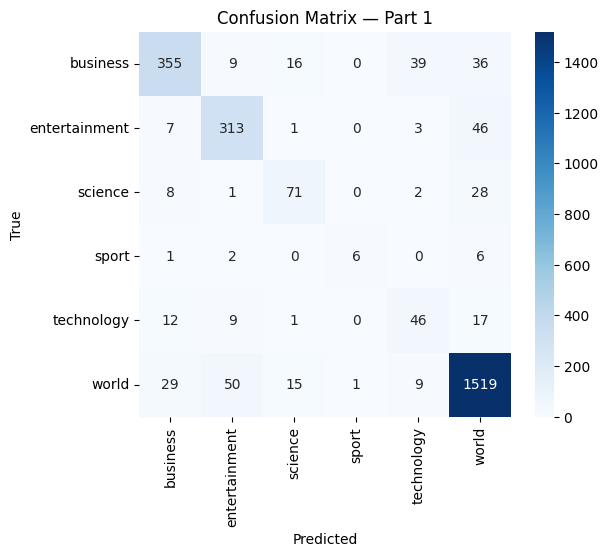

Test accuracy (Part 1): 0.8690744920993227


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for ids, mask, y in test_loader:
        ids, mask = ids.to(device), mask.to(device)
        logits = model(ids, mask)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(y.numpy())

print("=== Part 1: Transformer From Scratch — Test Report ===")
print(classification_report(all_true, all_preds, target_names=labels))

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix — Part 1')
plt.show()

transformer_test_acc = (np.array(all_preds) == np.array(all_true)).mean()
print("Test accuracy (Part 1):", transformer_test_acc)

---
# Part 2 — Sentence Embeddings (`all-MiniLM-L6-v2`) + a traditional ML model



In [ ]:
from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

X_train_emb = sbert_model.encode(train_df['text'].tolist(), show_progress_bar=True, batch_size=64)
X_val_emb   = sbert_model.encode(val_df['text'].tolist(), show_progress_bar=True, batch_size=64)
X_test_emb  = sbert_model.encode(test_df['text'].tolist(), show_progress_bar=True, batch_size=64)

y_train = train_df['label_id'].values
y_val   = val_df['label_id'].values
y_test  = test_df['label_id'].values

print(X_train_emb.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/150 [00:00<?, ?it/s]

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Batches:   0%|          | 0/42 [00:00<?, ?it/s]

(9568, 384)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train_full = np.vstack([X_train_emb, X_val_emb])
y_train_full = np.concatenate([y_train, y_val])

ml_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0),
    "SVM (RBF)": SVC(kernel='rbf', C=2.0, probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
}

ml_results = {}
for name, clf in ml_models.items():
    clf.fit(X_train_full, y_train_full)
    preds = clf.predict(X_test_emb)
    acc = accuracy_score(y_test, preds)
    ml_results[name] = (clf, preds, acc)
    print(f"{name}: test accuracy = {acc:.4f}")

Logistic Regression: test accuracy = 0.8740
SVM (RBF): test accuracy = 0.8980
Random Forest: test accuracy = 0.7972


=== Part 2: best model is SVM (RBF) with accuracy 0.8980 ===
               precision    recall  f1-score   support

     business       0.85      0.88      0.86       455
entertainment       0.88      0.88      0.88       370
      science       0.82      0.64      0.72       110
        sport       1.00      0.33      0.50        15
   technology       0.53      0.48      0.51        85
        world       0.94      0.95      0.94      1623

     accuracy                           0.90      2658
    macro avg       0.84      0.69      0.74      2658
 weighted avg       0.90      0.90      0.90      2658



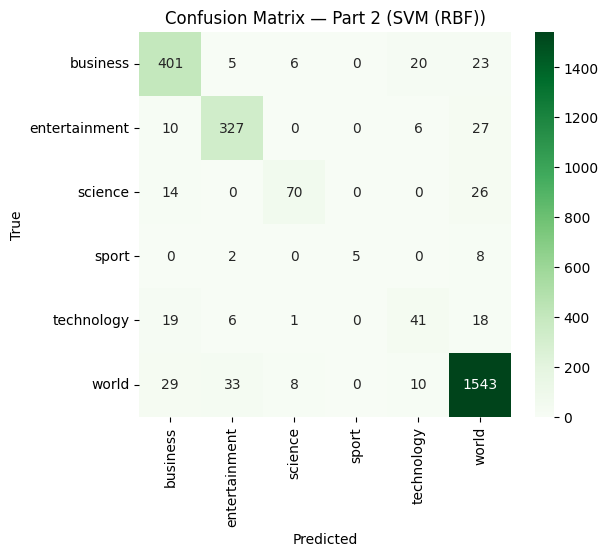

In [ ]:
best_name = max(ml_results, key=lambda k: ml_results[k][2])
best_clf, best_preds, best_acc = ml_results[best_name]

print(f"=== Part 2: best model is {best_name} with accuracy {best_acc:.4f} ===")
print(classification_report(y_test, best_preds, target_names=labels))

cm2 = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Greens')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'Confusion Matrix — Part 2 ({best_name})')
plt.show()

---
# Part 3 — Using a HuggingFace `transformers` pipeline on the same data




### 3.a) Zero-shot Pipeline (a quick trial with no training)

In [ ]:
from transformers import pipeline

zero_shot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 if torch.cuda.is_available() else -1,
)

sample_texts = test_df['text'].tolist()[:50]   # a small sample for a quick trial
sample_true = test_df['category'].tolist()[:50]

zs_preds = []
for text in sample_texts:
    result = zero_shot(text[:512], candidate_labels=labels)
    zs_preds.append(result['labels'][0])

zs_acc = np.mean([p == t for p, t in zip(zs_preds, sample_true)])
print("Zero-shot accuracy (sample of 50):", zs_acc)

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Zero-shot accuracy (sample of 50): 0.6


### 3.b) Real fine-tuning of DistilBERT, then using it in a `pipeline`

In [ ]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from datasets import Dataset as HFDataset

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf_dataset(dframe):
    return HFDataset.from_pandas(
        dframe[['text', 'label_id']].rename(columns={'label_id': 'label'}).reset_index(drop=True)
    )

train_hf = to_hf_dataset(train_df)
val_hf = to_hf_dataset(val_df)
test_hf = to_hf_dataset(test_df)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=256)

train_hf = train_hf.map(tokenize_fn, batched=True)
val_hf = val_hf.map(tokenize_fn, batched=True)
test_hf = test_hf.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

hf_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(labels), id2label=id2label, label2id=label2id
)

Map:   0%|          | 0/9568 [00:00<?, ? examples/s]

Map:   0%|          | 0/1064 [00:00<?, ? examples/s]

Map:   0%|          | 0/2658 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from sklearn.metrics import accuracy_score as sk_acc, f1_score

def compute_metrics(eval_pred):
    logits, labels_ = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": sk_acc(labels_, preds),
        "f1_macro": f1_score(labels_, preds, average="macro"),
    }

training_args = TrainingArguments(
    output_dir="/content/bbc-distilbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=20,
    report_to="none",
)

trainer = Trainer(
    model=hf_model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.270668,0.273485,0.912594,0.779993
2,0.166515,0.245927,0.922932,0.840325
3,0.105319,0.260728,0.927632,0.847319


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1794, training_loss=0.2511903799098471, metrics={'train_runtime': 188.1078, 'train_samples_per_second': 152.593, 'train_steps_per_second': 9.537, 'total_flos': 328670920304064.0, 'train_loss': 0.2511903799098471, 'epoch': 3.0})

In [ ]:
test_metrics = trainer.evaluate(test_hf)
print("=== Part 3: DistilBERT Fine-tuned — Test Metrics ===")
print(test_metrics)
trainer.save_model("/content/bbc-distilbert-final")
tokenizer.save_pretrained("/content/bbc-distilbert-final")

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.105319,0.324870,3,0.908202,0.779512


=== Part 3: DistilBERT Fine-tuned — Test Metrics ===
{'eval_loss': 0.32486966252326965, 'eval_accuracy': 0.908201655379985, 'eval_f1_macro': 0.7795120827957801}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/bbc-distilbert-final/tokenizer_config.json',
 '/content/bbc-distilbert-final/tokenizer.json')

In [ ]:
finetuned_pipeline = pipeline(
    "text-classification",
    model="/content/bbc-distilbert-final",
    tokenizer="/content/bbc-distilbert-final",
    device=0 if torch.cuda.is_available() else -1,
)

examples = test_df['text'].tolist()[:5]
for text in examples:
    pred = finetuned_pipeline(text[:512])
    print(pred)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'world', 'score': 0.9985149502754211}]
[{'label': 'world', 'score': 0.9217736124992371}]
[{'label': 'world', 'score': 0.9985777139663696}]
[{'label': 'world', 'score': 0.9987185001373291}]
[{'label': 'world', 'score': 0.9983572363853455}]


---
# Final comparison across the three approaches


In [ ]:
finetuned_test_acc = test_metrics.get('eval_accuracy', None)

summary = pd.DataFrame({
    "Approach": [
        "Part 1: Transformer from scratch (Word2Vec + PosEnc)",
        f"Part 2: MiniLM embeddings + {best_name}",
        "Part 3.a: Zero-shot pipeline (no training)",
        "Part 3.b: Fine-tuned DistilBERT pipeline",
    ],
    "Test Accuracy": [
        transformer_test_acc,
        best_acc,
        zs_acc,
        finetuned_test_acc,
    ]
})
summary

,Approach,Test Accuracy
0,Part 1: Transformer from scratch (Word2Vec + P...,0.869074
1,Part 2: MiniLM embeddings + SVM (RBF),0.898044
2,Part 3.a: Zero-shot pipeline (no training),0.600000
3,Part 3.b: Fine-tuned DistilBERT pipeline,0.908202
